# 2-Player **Diffusion** Augmentation for Imbalanced Anomaly Detection (Gamma noise)
### What the original paper does (3 players)
### What we change

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix

torch.manual_seed(0)
np.random.seed(0)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


## 1. Hyperparameters

In [21]:
batch_size        = 64
image_size        = 28
num_classes       = 3

timesteps         = 1000
noise_type        = 'gaussian'      # <<< 'gamma' (proposed)  or  'gaussian' (baseline noise) >>>
theta0            = 0.001        # Gamma initial scale (only used when noise_type='gamma')
diffusion_epochs  = 50

classifier_epochs = 50
learning_rate     = 2e-4
adam_betas        = (0.5, 0.9)   # as in the paper

target_per_class  = 800          # balance every class up to this many samples
per_class_test    = 500          # balanced test set size per class
gen_batch         = 128          # batch size used during sample generation

## 2. Imbalanced Fashion-MNIST

In [22]:
SEL    = [0, 2, 3]
REMAP  = {0: 0, 2: 1, 3: 2}
NAMES  = ['T-shirt', 'Pullover', 'Dress']

fm_train = datasets.FashionMNIST(root='../data', train=True,  download=True)
fm_test  = datasets.FashionMNIST(root='../data', train=False, download=True)

def collect(ds, counts):
    """Pull `counts[orig_label]` images per selected class, scaled to [-1, 1]."""
    X, Y = [], []
    for orig in SEL:
        idx = (ds.targets == orig).nonzero(as_tuple=False).squeeze(1)[:counts[orig]]
        imgs = ds.data[idx].float() / 255.0          # [n, 28, 28] in [0, 1]
        imgs = (imgs - 0.5) / 0.5                     # -> [-1, 1]
        X.append(imgs.unsqueeze(1))                   # [n, 1, 28, 28]
        Y.append(torch.full((len(idx),), REMAP[orig], dtype=torch.long))
    return torch.cat(X), torch.cat(Y)

train_counts = {0: 800, 2: 80, 3: 80}
X_train, y_train = collect(fm_train, train_counts)

test_counts = {0: per_class_test, 2: per_class_test, 3: per_class_test}
X_test, y_test = collect(fm_test, test_counts)

print("Imbalanced training set:")
for c in range(num_classes):
    print(f"  {NAMES[c]:8s}: {(y_train == c).sum().item()} samples")
print("Test set (balanced):")
for c in range(num_classes):
    print(f"  {NAMES[c]:8s}: {(y_test == c).sum().item()} samples")

Imbalanced training set:
  T-shirt : 800 samples
  Pullover: 80 samples
  Dress   : 80 samples
Test set (balanced):
  T-shirt : 500 samples
  Pullover: 500 samples
  Dress   : 500 samples


## 3. Player 1: class-conditional diffusion (U-Net)

In [23]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time.float()[:, None] * embeddings[None, :]
        return torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch))
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm = nn.GroupNorm(8, out_ch)

    def forward(self, x, t):
        h = self.conv1(x)
        h = h + self.time_mlp(t)[:, :, None, None]
        h = self.norm(F.silu(h))
        h = self.conv2(h)
        return self.norm(F.silu(h))

class UNet(nn.Module):
    """U-Net noise estimator, conditioned on timestep t AND class label y."""
    def __init__(self, num_classes=3):
        super().__init__()
        time_dim = 32
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim)
        )
        self.label_emb = nn.Embedding(num_classes, time_dim)   # <-- class conditioning

        self.down1 = Block(1, 64, time_dim)
        self.down2 = Block(64, 128, time_dim)
        self.down3 = Block(128, 256, time_dim)
        self.down4 = Block(256, 512, time_dim)
        self.bottleneck = Block(512, 512, time_dim)
        self.up1 = Block(512 + 512, 512, time_dim)
        self.up2 = Block(512 + 256, 256, time_dim)
        self.up3 = Block(256 + 128, 128, time_dim)
        self.up4 = Block(128 + 64, 64, time_dim)
        self.final_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x, t, y):
        t = self.time_mlp(t) + self.label_emb(y)          # combine time + class

        h1 = self.down1(x, t)
        h2 = self.down2(F.avg_pool2d(h1, 2), t)
        h3 = self.down3(F.avg_pool2d(h2, 2), t)
        h4 = self.down4(F.avg_pool2d(h3, 2), t)
        h  = self.bottleneck(F.avg_pool2d(h4, 2), t)

        h = F.interpolate(h, size=h4.shape[2:], mode='nearest'); h = self.up1(torch.cat([h, h4], 1), t)
        h = F.interpolate(h, size=h3.shape[2:], mode='nearest'); h = self.up2(torch.cat([h, h3], 1), t)
        h = F.interpolate(h, size=h2.shape[2:], mode='nearest'); h = self.up3(torch.cat([h, h2], 1), t)
        h = F.interpolate(h, size=h1.shape[2:], mode='nearest'); h = self.up4(torch.cat([h, h1], 1), t)
        return self.final_conv(h)

class Diffusion:
    """
    Unified diffusion process supporting Gaussian (DDPM) and Gamma (DDGM) noise.

    Both share x_t = sqrt(abar_t) * x0 + sqrt(1 - abar_t) * target, where `target` is the
    unit-variance noise the network predicts:
      - gaussian: target = eps ~ N(0, I)
      - gamma   : target = (gbar_t - kbar_t*theta_t) / sqrt(1 - abar_t),  gbar_t ~ Gamma(kbar_t, theta_t)
    """
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02,
                 noise_type='gamma', theta0=0.001):
        self.timesteps = timesteps
        self.noise_type = noise_type
        self.theta0 = theta0

        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
        self.alphas = 1. - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1. - self.alpha_bars)

        if noise_type == 'gamma':
            self.theta_t = torch.sqrt(self.alpha_bars) * theta0
            self.k_t = self.betas / (self.alpha_bars * theta0 ** 2)
            self.k_bar_t = torch.cumsum(self.k_t, dim=0)
            err = (self.k_bar_t * self.theta_t ** 2 - (1. - self.alpha_bars)).abs().max().item()
            print(f"[Diffusion/gamma] max |V(gbar_t) - (1 - abar_t)| = {err:.2e} (should be ~0)")
        elif noise_type != 'gaussian':
            raise ValueError("noise_type must be 'gamma' or 'gaussian'")

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.timesteps, size=(n,)).to(device)

    def _gamma_noise(self, shape, k_bar, theta):
        conc = k_bar.double().expand(shape).contiguous()
        rate = (1.0 / theta).double().expand(shape).contiguous()
        g = torch.distributions.Gamma(conc, rate).sample()
        return g - (k_bar * theta).double().expand(shape)

    def q_sample(self, x0, t):
        sqrt_ab = self.sqrt_alpha_bars[t][:, None, None, None]
        sqrt_omab = self.sqrt_one_minus_alpha_bars[t][:, None, None, None]
        if self.noise_type == 'gaussian':
            target = torch.randn_like(x0)
        else:
            k_bar = self.k_bar_t[t][:, None, None, None]
            theta = self.theta_t[t][:, None, None, None]
            noise = self._gamma_noise(x0.shape, k_bar, theta).to(x0.dtype)
            target = noise / sqrt_omab
        x_t = sqrt_ab * x0 + sqrt_omab * target
        return x_t, target

    def p_losses(self, model, x0, y, t):
        x_noisy, target = self.q_sample(x0, t)
        pred = model(x_noisy, t, y)
        return F.l1_loss(target, pred) if self.noise_type == 'gamma' else F.mse_loss(target, pred)

    @torch.no_grad()
    def sample(self, model, n, y, image_size, channels=1):
        """Class-conditional sampling; y is a LongTensor of length n."""
        model.eval()
        T = self.timesteps
        shape = (n, channels, image_size, image_size)

        if self.noise_type == 'gaussian':
            x_t = torch.randn(shape, device=device)
        else:
            x_t = self._gamma_noise(shape,
                                    self.k_bar_t[T - 1].view(1, 1, 1, 1),
                                    self.theta_t[T - 1].view(1, 1, 1, 1)).to(device).float()

        for i in reversed(range(0, T)):
            t = torch.full((n,), i, device=device, dtype=torch.long)
            pred = model(x_t, t, y)
            alpha = self.alphas[i]; beta = self.betas[i]
            sqrt_omab = self.sqrt_one_minus_alpha_bars[i]

            x_t = (x_t - (1 - alpha) / sqrt_omab * pred) / torch.sqrt(alpha)

            if i > 0:
                if self.noise_type == 'gaussian':
                    z = torch.randn_like(x_t)
                else:
                    z = self._gamma_noise(shape,
                                          self.k_bar_t[i - 1].view(1, 1, 1, 1),
                                          self.theta_t[i - 1].view(1, 1, 1, 1)).to(device).float()
                    z = z / self.sqrt_one_minus_alpha_bars[i - 1]   # normalize to unit variance
                x_t = x_t + torch.sqrt(beta) * z
        return x_t

## 4. Player 2: CNN classifier (paper architecture, Table 12)

In [24]:
class Classifier(nn.Module):
    """4 conv blocks (32, 32, 128, 256), kernel 4, stride 2, LeakyReLU(0.2), then softmax head."""
    def __init__(self, num_classes=3):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 4, stride=2, padding=1), nn.LeakyReLU(0.2))
        self.features = nn.Sequential(
            block(1, 32),     # 28 -> 14
            block(32, 32),    # 14 -> 7
            block(32, 128),   # 7  -> 3
            block(128, 256),  # 3  -> 1
        )
        self.head = nn.Linear(256, num_classes)

    def forward(self, x):
        h = self.features(x)
        h = h.flatten(1)
        return self.head(h)   # logits (use CrossEntropyLoss)

## 5. Train Player 1: conditional diffusion on the imbalanced data

In [25]:
unet = UNet(num_classes=num_classes).to(device)
diffusion = Diffusion(timesteps=timesteps, noise_type=noise_type, theta0=theta0)

opt_g = optim.AdamW(unet.parameters(), lr=learning_rate, weight_decay=1e-4)
sched_g = optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=diffusion_epochs)

diff_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

for epoch in range(diffusion_epochs):
    unet.train()
    pbar = tqdm(diff_loader)
    total = 0.0
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        t = diffusion.sample_timesteps(x.size(0))
        loss = diffusion.p_losses(unet, x, y, t)
        opt_g.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        opt_g.step()
        total += loss.item()
        pbar.set_description(f"[diffusion-{noise_type}] epoch {epoch} loss {loss.item():.4f}")
    sched_g.step()
    print(f"epoch {epoch} | avg loss {total/len(diff_loader):.4f}")

[diffusion-gaussian] epoch 0 loss 0.1492: 100%|██████████| 15/15 [00:00<00:00, 27.74it/s]


epoch 0 | avg loss 0.4519


[diffusion-gaussian] epoch 1 loss 0.1345: 100%|██████████| 15/15 [00:00<00:00, 33.24it/s]


epoch 1 | avg loss 0.1703


[diffusion-gaussian] epoch 2 loss 0.0684: 100%|██████████| 15/15 [00:00<00:00, 33.41it/s]


...

epoch 47 | avg loss 0.0529


[diffusion-gaussian] epoch 48 loss 0.0373: 100%|██████████| 15/15 [00:00<00:00, 33.23it/s]


epoch 48 | avg loss 0.0522


[diffusion-gaussian] epoch 49 loss 0.0695: 100%|██████████| 15/15 [00:00<00:00, 33.37it/s]

epoch 49 | avg loss 0.0479


## 6. Sanity check: visualize conditional samples

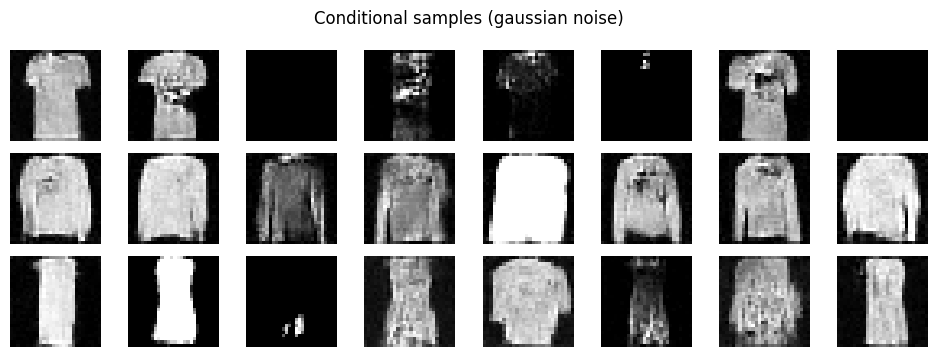

In [26]:
@torch.no_grad()
def show_class_samples(n_per_class=8):
    unet.eval()
    fig, axes = plt.subplots(num_classes, n_per_class, figsize=(n_per_class * 1.2, num_classes * 1.2))
    for c in range(num_classes):
        y = torch.full((n_per_class,), c, device=device, dtype=torch.long)
        imgs = diffusion.sample(unet, n_per_class, y, image_size).clamp(-1, 1).cpu()
        for j in range(n_per_class):
            ax = axes[c, j]
            ax.imshow(imgs[j, 0].numpy(), cmap='gray'); ax.axis('off')
        axes[c, 0].set_ylabel(NAMES[c])
    plt.suptitle(f"Conditional samples ({noise_type} noise)")
    plt.tight_layout(); plt.show()

show_class_samples()

## 7. Generate minority samples -> balanced training set

In [27]:
@torch.no_grad()
def generate_for_class(cls, n, batch=gen_batch):
    unet.eval()
    outs, remaining = [], n
    while remaining > 0:
        b = min(batch, remaining)
        y = torch.full((b,), cls, device=device, dtype=torch.long)
        imgs = diffusion.sample(unet, b, y, image_size).clamp(-1, 1).cpu()
        outs.append(imgs); remaining -= b
    return torch.cat(outs)[:n]

X_aug, y_aug = [X_train], [y_train]
for c in range(num_classes):
    n_have = (y_train == c).sum().item()
    n_gen = target_per_class - n_have
    if n_gen > 0:
        print(f"Generating {n_gen} samples for minority class '{NAMES[c]}' ...")
        gen = generate_for_class(c, n_gen)
        X_aug.append(gen)
        y_aug.append(torch.full((n_gen,), c, dtype=torch.long))

X_aug = torch.cat(X_aug)
y_aug = torch.cat(y_aug)
print("Balanced (augmented) training set:")
for c in range(num_classes):
    print(f"  {NAMES[c]:8s}: {(y_aug == c).sum().item()} samples")

Generating 720 samples for minority class 'Pullover' ...
Generating 720 samples for minority class 'Dress' ...
Balanced (augmented) training set:
  T-shirt : 800 samples
  Pullover: 800 samples
  Dress   : 800 samples


## 8. Train Player 2: classifier (baseline vs augmented)

In [28]:
def train_classifier(X, y, epochs, tag=""):
    clf = Classifier(num_classes).to(device)
    opt = optim.Adam(clf.parameters(), lr=learning_rate, betas=adam_betas)
    loader = DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        clf.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.cross_entropy(clf(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return clf

@torch.no_grad()
def evaluate(clf, X, y):
    clf.eval()
    preds = []
    for i in range(0, len(X), 256):
        preds.append(clf(X[i:i+256].to(device)).argmax(1).cpu())
    preds = torch.cat(preds).numpy()
    p, r, f, _ = precision_recall_fscore_support(y.numpy(), preds, average='macro', zero_division=0)
    return p, r, f, preds

clf_base = train_classifier(X_train, y_train, classifier_epochs, tag="baseline")
p0, r0, f0, pred0 = evaluate(clf_base, X_test, y_test)

clf_aug = train_classifier(X_aug, y_aug, classifier_epochs, tag="augmented")
p1, r1, f1, pred1 = evaluate(clf_aug, X_test, y_test)

## 9. Results

In [30]:
print("="*60)
print(f"Macro-averaged results on balanced test set  (noise_type = {noise_type})")
print("="*60)
print(f"{'Method':<28}{'Precision':>10}{'Recall':>10}{'F-score':>10}")
print(f"{'Baseline (imbalanced)':<28}{p0:>10.3f}{r0:>10.3f}{f0:>10.3f}")
print(f"{'Proposed (diffusion aug)':<28}{p1:>10.3f}{r1:>10.3f}{f1:>10.3f}")
print()
print("Per-class report - Baseline:")
print(classification_report(y_test.numpy(), pred0, target_names=NAMES, zero_division=0))
print("Per-class report - Proposed (diffusion augmentation):")
print(classification_report(y_test.numpy(), pred1, target_names=NAMES, zero_division=0))
print("Confusion matrix - Baseline:")
print(confusion_matrix(y_test.numpy(), pred0))
print("Confusion matrix - Proposed:")
print(confusion_matrix(y_test.numpy(), pred1))

Macro-averaged results on balanced test set  (noise_type = gaussian)
Method                       Precision    Recall   F-score
Baseline (imbalanced)            0.865     0.819     0.822
Proposed (diffusion aug)         0.907     0.903     0.904

Per-class report - Baseline:
              precision    recall  f1-score   support

     T-shirt       0.67      0.97      0.79       500
    Pullover       0.97      0.81      0.88       500
       Dress       0.96      0.68      0.79       500

    accuracy                           0.82      1500
   macro avg       0.86      0.82      0.82      1500
weighted avg       0.86      0.82      0.82      1500

Per-class report - Proposed (diffusion augmentation):
              precision    recall  f1-score   support

     T-shirt       0.85      0.94      0.90       500
    Pullover       0.96      0.88      0.92       500
       Dress       0.91      0.89      0.90       500

    accuracy                           0.90      1500
   macro avg     